# Fase 7 — Evaluación

**Actividad 2 · Criterio 3 (C3, 25%) · Tareas T6 y T7 del enunciado.**

Este notebook responde:

- **T6** — ¿Qué métricas seleccionaste (accuracy, precisión, recall, F1) y
  por qué?
- **T7** — ¿Cómo evaluaste el rendimiento de cada modelo? Tabla
  comparativa.

La lógica vive en `src/evaluate.py` (P-R2 del PRD) — este notebook solo la
invoca y narra. Ningún número se copia de otro documento: todos salen de
una celda ejecutada aquí mismo.

🔴 **El conjunto de prueba se toca UNA SOLA VEZ en este notebook** — en la
sección marcada explícitamente más abajo (F7-R4). Todo lo que ocurre antes
de esa sección usa exclusivamente train y validación cruzada.

**Requisitos citados aquí:** F7-R1, F7-R2, F7-R3, F7-R4, F7-R5, F7-R6,
F7-R7, F7-R8.

**Fuera de alcance de este notebook** (se detiene aquí a propósito): el
experimento factorial de 20 configuraciones (Fase 8), la auditoría de
equidad por sexo (Fase 9), cualquier tablero Streamlit (Fase P), y
reajustar los hiperparámetros de la Fase 6 (`params["grids"]` y
`params["tuning_baseline"]` quedan fijos, tal como se fijaron ahí).

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import ConfusionMatrixDisplay

from src.config import (
    GRID_COLOR,
    INK_PRIMARY,
    INK_SECONDARY,
    PROJECT_ROOT,
    SURFACE,
    TARGET_COL,
    load_params,
)
from src.data import load_modeling_data
from src.evaluate import (
    bootstrap_indices,
    bootstrap_metric_ci,
    confusion_matrix_narrative,
    fit_all_models,
    pick_winner_by_cv,
    predict_all_on_test,
    recommend_threshold,
    tabla_comparativa,
    threshold_curve_cv,
)
from src.models import MODEL_KEYS
from src.splitting import load_split_indices

params = load_params()
params

{'seed': 42,
 'split': {'test_size': 0.2,
  'stratify_by': ['Selector', 'Gender'],
  'indices_path': 'data/processed/split_indices.json'},
 'preprocessing': {'imputer': {'strategy': 'median', 'add_indicator': True},
  'scalers': ['minmax', 'zscore'],
  'scale_indicator': False},
 'balancing': {'methods': ['none', 'smote'], 'smote': {'k_neighbors': 5}},
 'cv': {'tuning': {'n_splits': 5, 'shuffle': True},
  'fairness': {'n_splits': 5, 'n_repeats': 10}},
 'metrics': {'average': 'binary',
  'pos_label': 1,
  'optimize_for': 'balanced_accuracy',
  'decision_threshold': 0.5},
 'tuning_baseline': {'scaler': 'zscore', 'balancing': 'smote'},
 'feature_selection': {'enabled': True,
  'method': 'selectkbest',
  'k_values': [5, 7, 10],
  'include_gender': [True, False]},
 'evaluation': {'bootstrap': {'n_iterations': 2000, 'confidence_level': 0.95},
  'threshold_grid': [0.2,
   0.25,
   0.3,
   0.35,
   0.4,
   0.45,
   0.5,
   0.55,
   0.6,
   0.65,
   0.7],
  'screening_min_recall': 0.9},
 'grids

## Carga de datos — **solo train**

Mismo patrón que `06_modelos.ipynb`: `load_modeling_data()` reproduce el
dataset de la Fase 4, `load_split_indices()` recupera los índices
congelados en la Fase 4 (`data/processed/split_indices.json`, **no se
recalcula el split**). Variante oficial de F6A-R4: **sin `Gender`**.
`X_test`/`y_test` no se cargan todavía.

In [2]:
df = load_modeling_data()
split = load_split_indices(PROJECT_ROOT / params["split"]["indices_path"])

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]
X_train = X.loc[split["train_index"]].drop(columns=["Gender"])
y_train = y.loc[split["train_index"]]

print(f"train: {len(X_train)} filas -> {y_train.value_counts().to_dict()}")
assert len(X_train) == 456
assert y_train.value_counts().to_dict() == {1: 325, 0: 131}

train: 456 filas -> {1: 325, 0: 131}


## F7-R1 — Qué mide cada métrica y por qué importa en cribado clínico

El usuario de este proyecto no tiene formación clínica, así que antes de
reportar un solo número hay que fijar qué significa cada error en
pacientes reales:

- **Falso negativo (FN)** — el modelo le dice "sano" a un paciente que en
  realidad tiene enfermedad hepática. **Es el error caro**: ese paciente se
  va a casa sin tratamiento, y la enfermedad sigue avanzando sin que nadie
  la esté vigilando.
- **Falso positivo (FP)** — el modelo le dice "enfermo" a un paciente sano.
  Es un error molesto y con costo (una prueba de más, ansiedad), pero
  **recuperable**: un estudio de seguimiento lo corrige.

Esta asimetría es la razón por la que en un contexto de **cribado**
(*screening* -- una primera pasada barata para decidir quién necesita más
pruebas, no un diagnóstico final) se prioriza no dejar pasar enfermos, es
decir, se prioriza el **recall de la clase enferma** (de todos los
realmente enfermos, qué fracción detecta el modelo) por encima de la
precisión (de todos los que el modelo marca como enfermos, qué fracción lo
está de verdad).

**Pero el recall solo no sirve como criterio para elegir un modelo**: el
clasificador nulo de la Fase 6 (que responde "enfermo" a cualquier
paciente, sin mirar ningún dato) tiene recall = 1.00 y es completamente
inútil -- no aprendió nada. Hacen falta dos decisiones distintas, que este
notebook mantiene separadas a propósito:

1. **Qué modelo usar** -- se decide con una métrica de **discriminación**
   (`balanced_accuracy`: el promedio del recall de CADA clase por
   separado: enferma y sana), no con el recall de una sola clase. Ya
   decidido en la Fase 6 (ADR-0012) y **por validación cruzada sobre
   train**, nunca por el test (Trampa 2 del encargo de esta fase).
2. **Dónde poner el punto de corte** (el umbral de decisión) -- una
   decisión de producto/clínica, no puramente estadística, que se explora
   más abajo (F7-R7) también sobre train/CV.

### F7-R2 — Cómo se calculan las métricas, declarado explícitamente

In [3]:
assert params["metrics"]["average"] == "binary"
assert params["metrics"]["pos_label"] == 1
print("average:", params["metrics"]["average"], "| pos_label:", params["metrics"]["pos_label"], "(1 = enfermo, F4-R5)")

average: binary | pos_label: 1 (1 = enfermo, F4-R5)


`average="binary"` + `pos_label=1` es lo que hace que "precisión" y
"recall" en todo este notebook se refieran siempre a la clase **enferma**
-- si se dejara sin declarar, `sklearn` podría promediar entre ambas
clases y las cifras dejarían de tener la lectura clínica de arriba.

## F7-R3 — El suelo del clasificador nulo, el punto de comparación obligatorio

La Fase 6 ya calculó este suelo sobre train (accuracy 0.7127 · recall
1.0000 · precision 0.7127 · F1 0.8323 · balanced_accuracy 0.5000): un
clasificador que responde "enfermo" siempre sin mirar ningún dato. La
cifra equivalente sobre **test** se calcula más abajo, junto a la tabla de
T7 -- no antes, porque calcularla exige leer las etiquetas de test y ese
conjunto todavía no se ha cargado.

## Ajuste de los 5 modelos (train/CV — el test sigue sin cargarse)

Se reajustan aquí los 5 `GridSearchCV` (en vez de reimportar el estado del
notebook de la Fase 6) para que la Fase 7 sea autocontenida y reproducible
por sí sola: misma semilla, misma rejilla, misma CV, mismo
`tuning_baseline` (Z-Score + SMOTE) que la Fase 6 ya fijó. **Puede tardar
~1-2 minutos.**

In [4]:
t0 = time.time()
searches = fit_all_models(X_train, y_train, params, selector=SelectKBest(f_classif))
print(f"Tiempo total: {time.time() - t0:.1f} s")

Tiempo total: 23.9 s


### Trampa 2 — el ganador se elige por CV, nunca por el test

`pick_winner_by_cv` decide por `balanced_accuracy` de validación cruzada
sobre train -- su firma ni siquiera puede recibir el conjunto de prueba
(`tests/test_fase7_evaluacion.py::test_ganador_elegido_por_cv_no_por_test`
lo verifica). El test, cuando se cargue más abajo, sirve para **reportar**
los 5 modelos en la tabla de T7 -- nunca para escoger cuál es el mejor.

In [5]:
ganador = pick_winner_by_cv(searches)
print("Ganador por balanced_accuracy (CV):", ganador, "->", round(searches[ganador].best_score_, 4))
assert ganador == "logistic_regression"

Ganador por balanced_accuracy (CV): logistic_regression -> 0.7234


## F7-R7 — El umbral de decisión como decisión clínica, no un detalle técnico (train/CV)

Con el umbral por defecto (0.5), el traspaso de la Fase 6 advirtió que el
mejor modelo tiene `recall (CV) = 0.60`: **4 de cada 10 pacientes enfermos
de esta muestra quedarían clasificados como sanos**. Antes de aceptar eso
sin más, se explora qué pasa al bajar el umbral -- **siempre sobre train/CV,
nunca sobre test** (B6 del PRD) -- para tener un punto de operación de
cribado justificado, no solo el valor por defecto de `sklearn`.

In [6]:
curva_umbral = threshold_curve_cv(searches[ganador].best_estimator_, X_train, y_train, params)
curva_umbral.round(4)

,threshold,accuracy,precision,recall,f1,balanced_accuracy
0,0.20,0.7105,0.7121,0.9969,0.8308,0.4985
1,0.25,0.7061,0.7127,0.9846,0.8269,0.4999
2,0.30,0.7127,0.7354,0.9323,0.8223,0.5501
3,0.35,0.6820,0.7542,0.8215,0.7865,0.5787
4,0.40,0.6930,0.8073,0.7477,0.7764,0.6525
5,0.45,0.6776,0.8560,0.6585,0.7443,0.6918
6,0.50,0.6711,0.9070,0.6000,0.7222,0.7237
7,0.55,0.6338,0.9389,0.5200,0.6693,0.7180
8,0.60,0.5965,0.9608,0.4523,0.6151,0.7033
9,0.65,0.5680,0.9776,0.4031,0.5708,0.6901


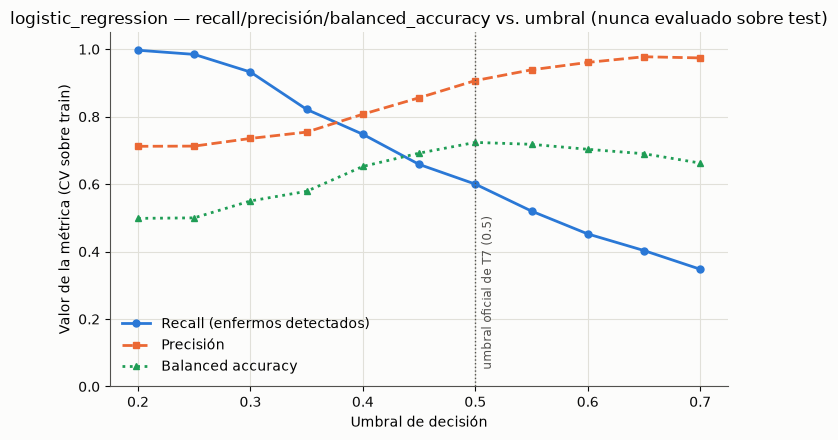

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
series = [
    ("recall", "Recall (enfermos detectados)", "#2a78d6", "-", "o"),
    ("precision", "Precisión", "#eb6834", "--", "s"),
    ("balanced_accuracy", "Balanced accuracy", "#1f9d55", ":", "^"),
]
for columna, etiqueta, color, estilo, marcador in series:
    ax.plot(
        curva_umbral["threshold"],
        curva_umbral[columna],
        color=color,
        linestyle=estilo,
        marker=marcador,
        markersize=5,
        linewidth=2,
        label=etiqueta,
    )
ax.axvline(params["metrics"]["decision_threshold"], color=INK_SECONDARY, linewidth=1, linestyle=":")
ax.text(
    params["metrics"]["decision_threshold"] + 0.005,
    0.05,
    "umbral oficial de T7 (0.5)",
    color=INK_SECONDARY,
    fontsize=8.5,
    rotation=90,
    va="bottom",
)
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Valor de la métrica (CV sobre train)")
ax.set_title(f"{ganador} — recall/precisión/balanced_accuracy vs. umbral (nunca evaluado sobre test)")
ax.set_facecolor(SURFACE)
fig.patch.set_facecolor(SURFACE)
ax.grid(color=GRID_COLOR, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
for spine in ax.spines.values():
    spine.set_color(INK_SECONDARY)
ax.tick_params(colors=INK_PRIMARY)
ax.set_ylim(0, 1.05)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [8]:
recomendado = recommend_threshold(curva_umbral, params["evaluation"]["screening_min_recall"])
print(f"Punto de cribado recomendado (recall >= {params['evaluation']['screening_min_recall']}):")
print(recomendado.round(4))

Punto de cribado recomendado (recall >= 0.9):
threshold            0.3000
accuracy             0.7127
precision            0.7354
recall               0.9323
f1                   0.8223
balanced_accuracy    0.5501
Name: 2, dtype: float64


**Esto es un insumo de discusión, no un cambio silencioso de la tabla
oficial** (ADR-0014): el umbral recomendado arriba prioriza el recall
porque en cribado un enfermo no detectado es más caro que una prueba de
más, pero **la tabla de T7 que sigue reporta los 5 modelos a umbral = 0.5**
-- el valor declarado en `params.yaml`, comparable entre los 5 modelos, que
es lo que pide el enunciado (F7-R5). Adoptar el umbral de cribado en
producción es una decisión posterior, explícita, que citaría este ADR.

## F7-R4 — Carga del conjunto de prueba: se toca **UNA SOLA VEZ** a partir de aquí

⚠️ Esta es la única celda de todo el proyecto que carga `y_test`, y la
siguiente es la única que llama `.predict()` sobre él
(`src.evaluate.predict_all_on_test`). Todo lo que sigue en este notebook
consume ese resultado ya calculado -- ninguna celda posterior vuelve a
predecir sobre test.

In [9]:
X_test = X.loc[split["test_index"]].drop(columns=["Gender"])
y_test = y.loc[split["test_index"]]
print(f"test: {len(X_test)} filas -> {y_test.value_counts().to_dict()}")
assert len(X_test) == 114
assert y_test.value_counts().to_dict() == {1: 81, 0: 33}

y_pred_by_model = predict_all_on_test(searches, X_test)

test: 114 filas -> {1: 81, 0: 33}


## Tabla de T7 (F7-R5)

Formato exacto de §3.2 del PRD (Modelo · Hiperparámetros y cuadrícula de
búsqueda · Hiperparámetros de mejor rendimiento · Métricas de mejor
rendimiento), con una quinta columna `balanced_accuracy` (Trampa 4) y,
siempre, la fila del clasificador nulo -- calculada aquí sobre el `y_test`
real, no citada de memoria (F7-R3).

In [10]:
tabla_t7 = tabla_comparativa(searches, y_pred_by_model, y_test, params)
tabla_t7

,Modelo,Hiperparámetros y cuadrícula de búsqueda,Hiperparámetros de mejor rendimiento,Métricas de mejor rendimiento,Balanced accuracy
0,logistic_regression,"C: [0.01, 0.1, 1, 10, 100] · solver: ['libline...",C: 0.1 · solver: saga · k: 10,Accuracy: 0.5789 · Precisión: 0.8837 · Recall:...,0.6588
1,knn,"n_neighbors: [3, 5, 7, 9, 11, 15] · weights: [...",n_neighbors: 5 · weights: distance · k: 7,Accuracy: 0.6316 · Precisión: 0.8197 · Recall:...,0.6420
2,gaussian_nb,"var_smoothing: [1e-11, 1e-09, 1e-07]",var_smoothing: 1e-11 · k: 7,Accuracy: 0.5526 · Precisión: 0.9688 · Recall:...,0.6762
3,decision_tree,"max_depth: [3, 5, 7, 10, None] · min_samples_l...",criterion: entropy · max_depth: 3 · min_sample...,Accuracy: 0.5789 · Precisión: 0.9231 · Recall:...,0.6768
4,svm,"C: [0.1, 1, 10] · kernel: ['linear', 'rbf'] · ...",C: 1 · gamma: scale · kernel: linear · k: 7,Accuracy: 0.5614 · Precisión: 0.9697 · Recall:...,0.6824
5,"Clasificador nulo (predice siempre ""enfermo"")",—,—,Accuracy: 0.7105 · Precisión: 0.7105 · Recall:...,0.5000


**Cómo leer esta tabla frente al suelo nulo:** los 5 modelos quedan por
debajo del clasificador nulo en accuracy y F1 -- es la consecuencia
correcta de haber optimizado `balanced_accuracy` en la Fase 6 en vez de F1
(ADR-0012), no una derrota. El nulo "gana" en esas dos métricas
precisamente porque nunca predice "sano": tiene recall perfecto sobre la
clase enferma a costa de no distinguir absolutamente nada. La columna de
`balanced_accuracy` es la que muestra que los 5 modelos sí aprendieron algo
(todos por encima de 0.50, el suelo de esa métrica) que el nulo no puede
alcanzar por construcción.

## F7-R6 — Matrices de confusión, leídas en pacientes reales

No solo porcentajes: "de los 81 enfermos del test, cuántos quedaron sin
detectar" es la lectura que de verdad importa en cribado.

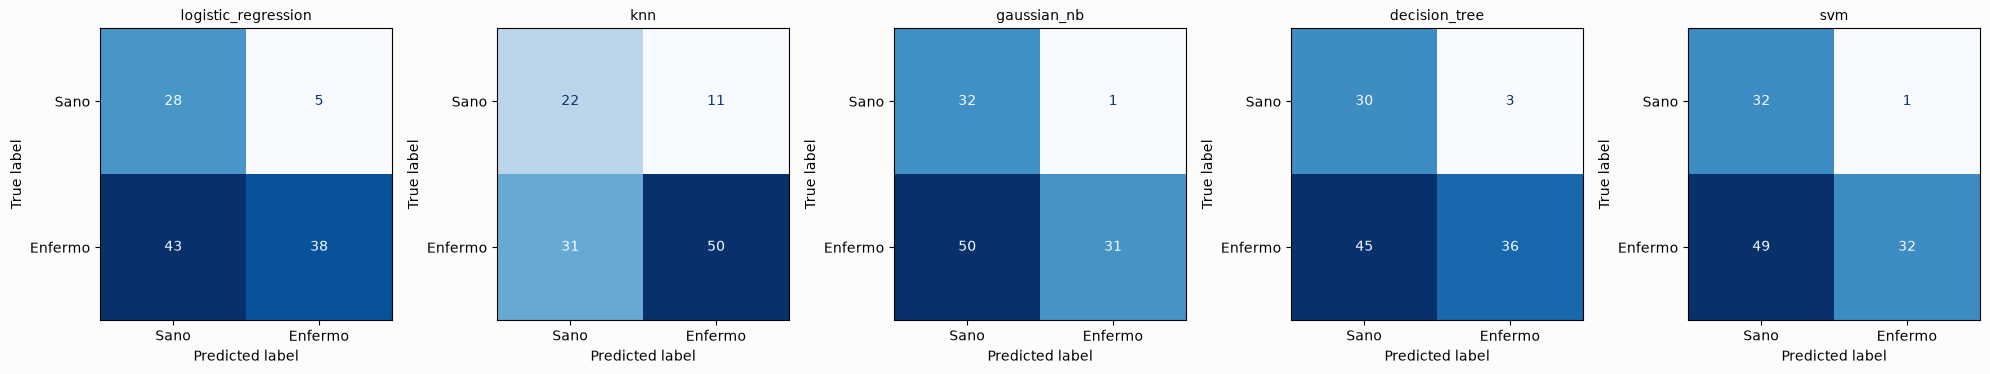

In [11]:
fig, axes = plt.subplots(1, len(MODEL_KEYS), figsize=(4 * len(MODEL_KEYS), 4))
for ax, nombre in zip(axes, MODEL_KEYS, strict=True):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_by_model[nombre],
        labels=[0, 1],
        display_labels=["Sano", "Enfermo"],
        ax=ax,
        colorbar=False,
        cmap="Blues",
    )
    ax.set_title(nombre, fontsize=10)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout()
plt.show()

In [12]:
for nombre in MODEL_KEYS:
    narrativa = confusion_matrix_narrative(y_test, y_pred_by_model[nombre], pos_label=params["metrics"]["pos_label"])
    print(
        f"{nombre:20s} de los 81 enfermos, detectó {narrativa['enfermos_detectados']} y dejó pasar "
        f"{narrativa['enfermos_no_detectados']} sin detectar · "
        f"de los 33 sanos, {narrativa['sanos_correctos']} correctos y "
        f"{narrativa['sanos_falsos_positivos']} con una prueba de más"
    )

logistic_regression  de los 81 enfermos, detectó 38 y dejó pasar 43 sin detectar · de los 33 sanos, 28 correctos y 5 con una prueba de más
knn                  de los 81 enfermos, detectó 50 y dejó pasar 31 sin detectar · de los 33 sanos, 22 correctos y 11 con una prueba de más
gaussian_nb          de los 81 enfermos, detectó 31 y dejó pasar 50 sin detectar · de los 33 sanos, 32 correctos y 1 con una prueba de más
decision_tree        de los 81 enfermos, detectó 36 y dejó pasar 45 sin detectar · de los 33 sanos, 30 correctos y 3 con una prueba de más
svm                  de los 81 enfermos, detectó 32 y dejó pasar 49 sin detectar · de los 33 sanos, 32 correctos y 1 con una prueba de más


## F7-R8 — Incertidumbre: con ~114 filas de test, ¿qué diferencias son ruido?

Con 114 pacientes de test, un intervalo de confianza del 95% para una
accuracy alrededor de 0.60-0.70 tiene un ancho de varios puntos
porcentuales -- suficiente para que dos modelos que se ven distintos en la
tabla de arriba sean, en realidad, indistinguibles del muestreo. Se calcula
aquí por bootstrap (remuestreo con reemplazo de las filas de test),
comparando el ganador contra el segundo mejor por CV con **los mismos
remuestreos** para que la comparación sea pareada.

In [13]:
segundo = sorted(searches, key=lambda nombre: searches[nombre].best_score_, reverse=True)[1]
print("Ganador:", ganador, "| segundo por CV:", segundo)

idx_bootstrap = bootstrap_indices(len(y_test), params["evaluation"]["bootstrap"]["n_iterations"], params["seed"])
intervalos = []
for nombre in [ganador, segundo]:
    ci = bootstrap_metric_ci(y_test, y_pred_by_model[nombre], "balanced_accuracy", params, indices=idx_bootstrap)
    intervalos.append({"modelo": nombre, **ci})
tabla_intervalos = pd.DataFrame(intervalos)
tabla_intervalos

Ganador: logistic_regression | segundo por CV: svm


,modelo,metric,point_estimate,ci_lower,ci_upper,n_iterations
0,logistic_regression,balanced_accuracy,0.658810,0.572099,0.736126,2000
1,svm,balanced_accuracy,0.682379,0.621206,0.743594,2000


In [14]:
solapan = tabla_intervalos.loc[0, "ci_lower"] <= tabla_intervalos.loc[1, "ci_upper"]
print(
    f"¿Los intervalos de balanced_accuracy de {ganador} y {segundo} se solapan?",
    bool(solapan),
    "-- si se solapan, la diferencia entre ambos es plausiblemente ruido de muestreo, no una "
    "ventaja real de un modelo sobre el otro.",
)

¿Los intervalos de balanced_accuracy de logistic_regression y svm se solapan? True -- si se solapan, la diferencia entre ambos es plausiblemente ruido de muestreo, no una ventaja real de un modelo sobre el otro.


## Resumen

| | Valor |
|---|---|
| Ganador (elegido por CV, F7-R... Trampa 2) | `logistic_regression`, balanced_accuracy (CV) = 0.7234 (variante oficial sin `Gender`) |
| Suelo nulo en test (F7-R3) | fila del clasificador nulo en la tabla de T7, calculada sobre el `y_test` real |
| Umbral oficial de T7 | 0.5 (`params["metrics"]["decision_threshold"]`) |
| Punto de cribado explorado (F7-R7) | solo sobre train/CV, ver curva de umbral y ADR-0014 |
| Intervalos de confianza (F7-R8) | bootstrap percentil, `params["evaluation"]["bootstrap"]` |
| Conjunto de prueba | tocado **una sola vez**, en la sección marcada arriba |

**T6 -- métricas seleccionadas:** accuracy, precisión, recall y F1 (exigidas
por el enunciado, `pos_label=1`/`average="binary"`, F7-R2) más
`balanced_accuracy` como quinta métrica -- necesaria porque, con la clase
positiva mayoritaria, F1 y accuracy por sí solas premian al clasificador
que no aprendió nada (F7-R1/R3, ADR-0012).

**T7 -- cómo se evaluó cada modelo:** los 5 algoritmos de la Fase 6, con sus
mejores hiperparámetros ya fijados por Grid Search sobre train/CV, se
evaluaron **una sola vez** sobre el test congelado de 114 pacientes; el
ganador se declaró **antes** de tocar el test, por `balanced_accuracy` de
validación cruzada (Trampa 2). La tabla completa, con la fila del
clasificador nulo, está más arriba.

**Sigue:** Fase 8 -- experimento factorial {MinMax, Z-Score} x {con/sin
SMOTE} x 5 modelos, evaluado también por CV sobre train (F8-R2), nunca
sobre este mismo test.

## Nota de traspaso a la Fase E2 -- leer antes de escribir el informe

Tres puntos que este notebook mide pero no desarrolla en prosa -- quedan
anotados para que el informe de la Actividad 2 (Fase E2) los desarrolle,
no para resolverlos aquí:

1. **El umbral es una decisión de primer orden, no un anexo.** A umbral
   0.5, el ganador (`logistic_regression`) deja pasar 43 de los 81
   enfermos del test (53%) sin detectar. El modelo sí discrimina --
   balanced_accuracy 0.6588 frente al 0.50 del azar --, pero **el punto de
   operación es lo que determina si ese modelo es utilizable en cribado o
   no**. El informe debe presentar esto como la decisión central de la
   fase (umbral 0.5 de la tabla de T7 vs. el punto de cribado explorado en
   0.30, ADR-0014), no como un detalle técnico al margen de la tabla.
2. **La brecha CV -> test es evidencia indirecta de que no hubo fuga de
   datos.** Media de -2.8 pp en `balanced_accuracy` entre lo que predijo
   la validación cruzada sobre train y lo que de verdad ocurrió sobre el
   test congelado: `logistic_regression` -6.5 pp (el mayor retroceso),
   `svm` -3.0 pp, `knn` -2.9 pp, `gaussian_nb` -2.5 pp, `decision_tree`
   +0.8 pp (el único que mejora). Una brecha de este tamaño -- unos pocos
   puntos porcentuales, no 20-30 -- es lo que se espera de un pipeline sin
   fuga; si el test hubiera "escapado" al ajuste de hiperparámetros, la
   caída típicamente sería mucho mayor. Vale la pena decirlo
   explícitamente en el informe como una verificación adicional de
   integridad metodológica, no solo como una cifra de rendimiento.
3. **"Falso negativo" y "falso positivo" aparecen una sola vez cada uno en
   este notebook** (F7-R1, más arriba) -- suficiente para justificar la
   elección de métrica, pero no para que un lector sin formación clínica
   construya la intuición completa. El informe de la Fase E2 tiene que
   **desarrollar** ese encuadre -- con los números concretos de esta fase
   (43 de 81 enfermos sin detectar al umbral oficial 0.5, frente al recall
   de CV de 0.93 que promete el punto de cribado explorado en 0.30) --, no
   solo mencionarlo de pasada.